# Feature Engineering: Complete Case Analysis (CCA)
### Handling Missing Data via Listwise Deletion: Foundations, Assumptions, and Distribution Diagnostics

---

### Scope & Focus of This Notebook
- **Primary Topic**: Complete Case Analysis (CCA) — also called **Listwise Deletion** — where rows containing missing values are removed from the dataset.
- **What You Will Learn**:
  1. What Complete Case Analysis is and how it mechanically purges incomplete rows.
  2. Manual row removal in pure Python before using automated library methods.
  3. The foundational statistical assumption: **MCAR (Missing Completely At Random)**.
  4. The 5% rule of thumb: When CCA is statistically viable vs. when it wastes excessive data.
  5. The danger of non-random missingness: How CCA introduces **selection bias** and population shifts.
  6. Diagnostic distribution verification:
     - Numerical features: Mean, median, standard deviation, variance ratio, and KDE plots.
     - Categorical features: Class proportions and side-by-side bar plots.
  7. Real-world Titanic Case Studies:
     - **Safe CCA**: `Embarked` (0.22% missing $\to$ 0.0% distribution shift).
     - **Unsafe/Biased CCA**: `Age` (19.87% missing $\to$ MAR pattern and -5.39% loss of 3rd class representation).
     - **Catastrophic CCA**: `Cabin` (77.10% missing $\to$ discarding 77% of rows vs. column removal).
  8. Head-to-Head Machine Learning Experiment: Training on complete cases and understanding the **critical production dilemma** (what happens when live inference data has nulls).
- **What We Will NOT Cover Here**:
  - Imputation techniques (Mean, Median, Arbitrary Value, End of Distribution, KNN, MICE) are covered in subsequent dedicated modules.
  - Tree-specific internal missing-value routing is covered in tree algorithm modules.

---

## 1. Setup & Environment Verification

### What are we doing?
We import data manipulation, visualization, and machine learning libraries, and load the Titanic dataset with robust path resolution.

#### What do these libraries do here?
- `pandas`: Tabular data structures and missing data filtering (`.dropna()`, `.isnull()`).
- `numpy`: Numerical calculations and NaN representations (`np.nan`).
- `matplotlib.pyplot` & `seaborn`: Visualizing distributions (KDE plots, bar plots) before and after CCA.
- `sklearn`: Preprocessing (`StandardScaler`, `OneHotEncoder`, `ColumnTransformer`), modeling (`RandomForestClassifier`), and train/test evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Clean visualization settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Robust dataset path resolution
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic Dataset: {df.shape[0]} rows, {df.shape[1]} columns")


Loaded Titanic Dataset: 891 rows, 12 columns


## 2. Manual Understanding on a Simple Toy Dataset

### What are we doing?
Before calling library functions, we build a 4-row employee dataset with intentional missing values to see exactly how Listwise Deletion operates row by row.

#### What does the data look like?
- Row 0: Fully complete (`Age: 25`, `Salary: 50,000`, `City: Delhi`).
- Row 1: `Salary` is missing (`NaN`).
- Row 2: `Age` is missing (`NaN`).
- Row 3: Fully complete (`Age: 28`, `Salary: 60,000`, `City: Gurgaon`).


In [2]:
# 1. Create simple toy DataFrame
toy_df = pd.DataFrame({
    'Age': [25.0, 30.0, np.nan, 28.0],
    'Salary': [50000.0, np.nan, 70000.0, 60000.0],
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Gurgaon']
})

print("--- Original Toy Dataset ---")
display(toy_df)


--- Original Toy Dataset ---


,Age,Salary,City
0,25.0,50000.0,Delhi
1,30.0,NaN,Mumbai
2,NaN,70000.0,Delhi
3,28.0,60000.0,Gurgaon


### Manual Row-by-Row Inspection

### What are we doing?
We manually inspect each row for nulls using boolean logic:
1. `toy_df.isnull()` creates a boolean mask where `True` indicates a missing value.
2. `.any(axis=1)` checks if **any** column in a given row has `True`.
3. Inverting the mask (`~`) selects only rows that are 100% complete.


In [3]:
# Boolean mask indicating whether any value in the row is missing
has_missing = toy_df.isnull().any(axis=1)

print("--- Row Missingness Status ---")
for idx, is_miss in enumerate(has_missing):
    status = "DISCARD (Contains NaN)" if is_miss else "RETAIN (Complete)"
    print(f"Row {idx}: {status}")

# Filter complete rows manually
toy_manual_cca = toy_df[~has_missing]

print("\n--- Dataset After Manual CCA ---")
display(toy_manual_cca)


--- Row Missingness Status ---
Row 0: RETAIN (Complete)
Row 1: DISCARD (Contains NaN)
Row 2: DISCARD (Contains NaN)
Row 3: RETAIN (Complete)

--- Dataset After Manual CCA ---


,Age,Salary,City
0,25.0,50000.0,Delhi
3,28.0,60000.0,Gurgaon


## 3. Library Implementation with Pandas: `DataFrame.dropna()`

### Meaningful Function Explanation: `DataFrame.dropna(axis=0, how='any', subset=None)`

1. **What is this function?**  
   Pandas' built-in method for removing rows (or columns) that contain missing (`NaN` or `None`) values.
2. **Why did we use it?**  
   To automate Complete Case Analysis across tabular datasets in a single, standardized, highly optimized operation.
3. **What does it take as input?**  
   - `axis`: `0` (or `'index'`) to drop rows; `1` (or `'columns'`) to drop columns. Default is `0`.
   - `how`: `'any'` drops the row if at least one value is null; `'all'` drops the row only if every value is null. Default is `'any'`.
   - `subset`: List of column names to check. If specified, only missing values in these designated columns trigger row removal.
   - `inplace`: If `True`, modifies the DataFrame directly. Default is `False` (returns a clean copy).
4. **What does it return?**  
   `pd.DataFrame`: A new DataFrame containing only rows that satisfy the non-null criteria.
5. **How does it work internally?**  
   It evaluates the underlying NumPy null-bitmask across the selected columns, computes row-level boolean reductions in optimized C code, and returns a sliced view/copy with updated index positions.
6. **Why did we choose this approach?**  
   It is the standard, battle-tested implementation in the Python data science ecosystem, performing orders of magnitude faster than Python loops.
7. **What will happen if we don't use it?**  
   We would have to write custom boolean indexing masks manually for every table and subset.
8. **Concrete Before / After Example:**  
   - Input: 4 rows (2 rows containing nulls)  
   - Output of `toy_df.dropna()`: Exactly 2 complete rows retained.


In [4]:
# 1. Global CCA (removes rows with ANY missing value)
toy_cca_all = toy_df.dropna()

# 2. Targeted CCA (removes rows ONLY if 'Age' is missing)
toy_cca_age = toy_df.dropna(subset=['Age'])

print("--- Dropna Across All Columns ---")
display(toy_cca_all)

print("\n--- Dropna Targeted on 'Age' Column Only ---")
display(toy_cca_age)


--- Dropna Across All Columns ---


,Age,Salary,City
0,25.0,50000.0,Delhi
3,28.0,60000.0,Gurgaon



--- Dropna Targeted on 'Age' Column Only ---


,Age,Salary,City
0,25.0,50000.0,Delhi
1,30.0,NaN,Mumbai
3,28.0,60000.0,Gurgaon


## 4. Diagnosing Missingness in Real-World Data: Titanic Case Study

### What are we doing?
We compute the exact missingness percentage for every feature in the Titanic dataset to determine which features are candidates for Complete Case Analysis.

$$\text{Missing Percentage} = \left(\frac{\text{Null Count}}{\text{Total Rows}}\right) \times 100$$


In [5]:
null_counts = df.isnull().sum()
null_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': null_counts,
    'Missing_Percentage': null_percent
}).sort_values(by='Missing_Percentage', ascending=False)

# Display only columns that have missing values
missing_active = missing_summary[missing_summary['Missing_Count'] > 0]

print("--- Features With Missing Values ---")
display(missing_active)


--- Features With Missing Values ---


,Missing_Count,Missing_Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### Categorizing Missingness into 3 Operational Tiers

### What are we doing?
We plot the missingness percentages to observe the three distinct tiers of missing data:
1. **Tier 1: Low Missingness ($< 5\%$) $\implies$ `Embarked` (0.22%)**: Prime candidate for CCA!
2. **Tier 2: Moderate Missingness ($10\% - 30\%$) $\implies$ `Age` (19.87%)**: Borderline; risk of severe sample loss and selection bias.
3. **Tier 3: Extreme Missingness ($> 70\%$) $\implies$ `Cabin` (77.10%)**: Disastrous for CCA; dropping rows would destroy 77% of the dataset!


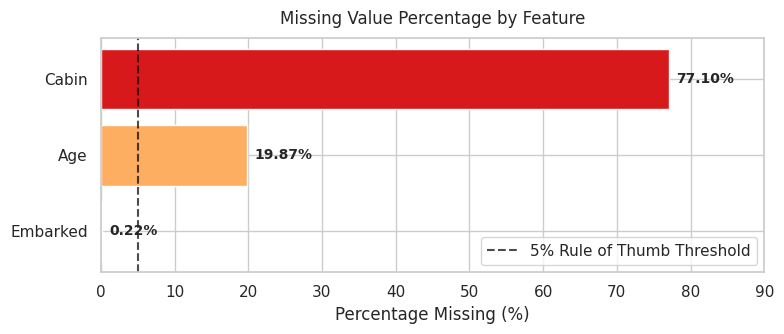

In [6]:
plt.figure(figsize=(8, 3.5))
bars = plt.barh(missing_active.index[::-1], missing_active['Missing_Percentage'][::-1], color=['#2b83ba', '#fdae61', '#d7191c'])
plt.title('Missing Value Percentage by Feature', fontsize=12, pad=10)
plt.xlabel('Percentage Missing (%)')

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 1, bar.get_y() + bar.get_height()/2.0, f"{xval:.2f}%", va='center', fontweight='bold', fontsize=10)

plt.xlim(0, 90)
plt.axvline(x=5.0, color='black', linestyle='--', alpha=0.7, label='5% Rule of Thumb Threshold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. Diagnostic Verification: Checking Distribution Preservation

### Meaningful Function Explanation: `check_distribution_shift(df_before, df_after, column, is_categorical=False)`

1. **What is this function?**  
   A diagnostic audit function that quantifies whether removing missing rows altered the statistical distribution of a feature.
2. **Why did we create it?**  
   Complete Case Analysis is only statistically valid if the remaining subset preserves the original population distribution. A reusable audit tool enables rapid before-and-after checks on means, variances, and category proportions.
3. **What does it take as input?**  
   - `df_before` (`pd.DataFrame`): The dataset prior to dropping rows.
   - `df_after` (`pd.DataFrame`): The dataset after applying Complete Case Analysis.
   - `column` (`str`): The name of the feature to evaluate.
   - `is_categorical` (`bool`, default=False): Flag indicating whether to analyze class percentages (`True`) or numerical moments (`False`).
4. **What does it return?**  
   `pd.DataFrame`: A comparison table showing:
   - For categorical features: Category proportions Before (%), After (%), and Shift Difference (%).
   - For numerical features: Mean, Median, Standard Deviation, and Variance Ratio ($\text{Var}_{\text{after}} / \text{Var}_{\text{before}}$).
5. **How does it work internally?**  
   - If categorical: Computes normalized `value_counts(normalize=True) * 100` on both datasets and subtracts them.
   - If numerical: Computes `.mean()`, `.median()`, `.std()`, and `.var()` on both subsets and calculates absolute differences and variance ratio.
6. **Why did we choose this approach?**  
   It provides an immediate quantitative verdict without relying purely on subjective visual guesses.
7. **What will happen if we don't use it?**  
   We could silently introduce severe selection bias into our training data without knowing that our sample distribution changed.
8. **Concrete Before / After Example:**  
   - Input: `df` (raw) vs `df_clean` (CCA on Embarked)  
   - Output: Shows port `S` proportion shifted by exactly `0.00%`.


In [7]:
def check_distribution_shift(df_before, df_after, column, is_categorical=False):
    if is_categorical:
        prop_before = (df_before[column].value_counts(normalize=True) * 100).round(2)
        prop_after = (df_after[column].value_counts(normalize=True) * 100).round(2)
        shift_df = pd.DataFrame({'Before (%)': prop_before, 'After (%)': prop_after})
        shift_df['Difference (%)'] = (shift_df['After (%)'] - shift_df['Before (%)']).round(2)
        return shift_df
    else:
        s_b = df_before[column].dropna()
        s_a = df_after[column].dropna()
        var_ratio = (s_a.var() / s_b.var()) if s_b.var() != 0 else np.nan
        metrics = {
            'Mean': [round(s_b.mean(), 2), round(s_a.mean(), 2), round(s_a.mean() - s_b.mean(), 2)],
            'Median': [round(s_b.median(), 2), round(s_a.median(), 2), round(s_a.median() - s_b.median(), 2)],
            'Std Dev': [round(s_b.std(), 2), round(s_a.std(), 2), round(s_a.std() - s_b.std(), 2)],
            'Variance Ratio': [1.0, round(var_ratio, 4), round(var_ratio - 1.0, 4)]
        }
        return pd.DataFrame(metrics, index=['Before CCA', 'After CCA', 'Difference'])

print("Distribution check function defined successfully.")


Distribution check function defined successfully.


## 6. Case Study 1: Safe CCA on Low-Missingness (`Embarked`)

### What are we doing?
`Embarked` has only 2 missing values out of 891 (0.22% missing).
1. We apply `df.dropna(subset=['Embarked'])` to remove the 2 incomplete rows.
2. We evaluate whether the proportions of boarding ports (`S`, `C`, `Q`) changed.
3. We check if numerical features (`Age`, `Fare`) suffered any distortion.

#### Why is this MCAR?
The two missing ports were archival recording omissions for two first-class passengers who boarded at Southampton. With only 2 rows lost out of 891, the sample size reduction is negligible.


In [8]:
# Perform CCA on Embarked
df_emb_cca = df.dropna(subset=['Embarked'])

print(f"Original Dataset Rows: {len(df)}")
print(f"Rows After CCA on Embarked: {len(df_emb_cca)} (Rows Removed: {len(df) - len(df_emb_cca)})")
print(f"Data Loss Percentage: {((len(df) - len(df_emb_cca)) / len(df) * 100):.2f}%")

# Audit categorical shift in Embarked
emb_shift = check_distribution_shift(df, df_emb_cca, 'Embarked', is_categorical=True)
print("\n--- Embarked Distribution Shift ---")
display(emb_shift)


Original Dataset Rows: 891
Rows After CCA on Embarked: 889 (Rows Removed: 2)
Data Loss Percentage: 0.22%

--- Embarked Distribution Shift ---


,Before (%),After (%),Difference (%)
Embarked,,,
S,72.44,72.44,0.0
C,18.90,18.90,0.0
Q,8.66,8.66,0.0


### Visualizing Embarked Category Proportions Before vs. After CCA

### What are we doing?
We plot the category percentages side-by-side to verify visual preservation.

#### What does the output mean?
Look at the bars: Southampton (`S`), Cherbourg (`C`), and Queenstown (`Q`) have **identical** heights before and after CCA! The difference is **0.0%**. This confirms that CCA on `Embarked` is 100% safe.


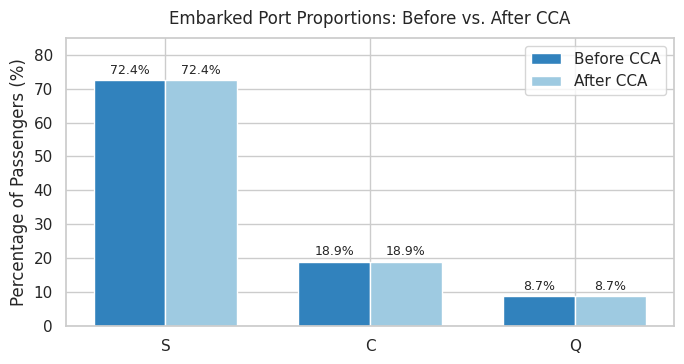

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.8))
x = np.arange(len(emb_shift))
width = 0.35

rects1 = ax.bar(x - width/2, emb_shift['Before (%)'], width, label='Before CCA', color='#3182bd')
rects2 = ax.bar(x + width/2, emb_shift['After (%)'], width, label='After CCA', color='#9ecae1')

ax.set_title('Embarked Port Proportions: Before vs. After CCA', fontsize=12, pad=10)
ax.set_ylabel('Percentage of Passengers (%)')
ax.set_xticks(x)
ax.set_xticklabels(emb_shift.index)
ax.legend()
ax.set_ylim(0, 85)

for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Case Study 2: Biased CCA on Moderate-Missingness (`Age`)

### What are we doing?
`Age` has 177 missing values (19.87% of the entire dataset).
Before dropping 177 rows, we must test: **Is missingness in `Age` purely random (MCAR)?**

#### Testing the MCAR Assumption:
We group the dataset by passenger class (`Pclass`) and measure the percentage of missing ages within each class.


In [10]:
# Checking Age missingness rate by Passenger Class (Pclass)
age_missing_by_pclass = df.groupby('Pclass')['Age'].apply(
    lambda s: pd.Series({
        'Total_Passengers': len(s),
        'Missing_Ages': s.isnull().sum(),
        'Missing_Rate (%)': round(s.isnull().mean() * 100, 2)
    })
).unstack()

print("--- Age Missingness Grouped by Ticket Class ---")
display(age_missing_by_pclass)


--- Age Missingness Grouped by Ticket Class ---


,Total_Passengers,Missing_Ages,Missing_Rate (%)
Pclass,,,
1,216.0,30.0,13.89
2,184.0,11.0,5.98
3,491.0,136.0,27.70


### The Critical Revelation: Missingness is NOT Random!

Look at the missingness rates:
- **1st Class (`Pclass 1`)**: 13.89% missing
- **2nd Class (`Pclass 2`)**: 5.98% missing
- **3rd Class (`Pclass 3`)**: **27.70% missing!**

Third-class passengers were **nearly 5 times more likely** to have missing age records than second-class passengers!
This is **NOT MCAR**; it is **MAR (Missing At Random)** because missingness directly correlates with ticket class.

#### What happens if we apply CCA on `Age`?
Let's drop all 177 rows and observe the resulting population distortion!


In [11]:
# Apply CCA on Age
df_age_cca = df.dropna(subset=['Age'])

print(f"Original Rows: {len(df)}")
print(f"Rows After CCA on Age: {len(df_age_cca)} (Rows Lost: {len(df) - len(df_age_cca)})")
print(f"Total Dataset Loss: {((len(df) - len(df_age_cca)) / len(df) * 100):.2f}%")

# Audit Pclass shift
pclass_shift = check_distribution_shift(df, df_age_cca, 'Pclass', is_categorical=True)
print("\n--- Pclass Distribution Shift After CCA on Age ---")
display(pclass_shift)

# Audit Fare shift
fare_shift = check_distribution_shift(df, df_age_cca, 'Fare', is_categorical=False)
print("\n--- Fare Distribution Shift After CCA on Age ---")
display(fare_shift)


Original Rows: 891
Rows After CCA on Age: 714 (Rows Lost: 177)
Total Dataset Loss: 19.87%

--- Pclass Distribution Shift After CCA on Age ---


,Before (%),After (%),Difference (%)
Pclass,,,
3,55.11,49.72,-5.39
1,24.24,26.05,1.81
2,20.65,24.23,3.58



--- Fare Distribution Shift After CCA on Age ---


,Mean,Median,Std Dev,Variance Ratio
Before CCA,32.20,14.45,49.69,1.000
After CCA,34.69,15.74,52.92,1.134
Difference,2.49,1.29,3.23,0.134


### Visualizing the Statistical Distortion Caused by Biased CCA

### What are we doing?
We plot:
1. **The Pclass Shift**: Third-class passenger representation collapses by **-5.39 percentage points** (from 55.11% to 49.72%), while upper-class proportions artificially swell!
2. **The Fare KDE Curve**: Because poorer passengers were disproportionately deleted, the observed `Fare` distribution shifts to the right, inflating the mean fare from **$32.20 to $34.69** and distorting variance by **+13.4%**!


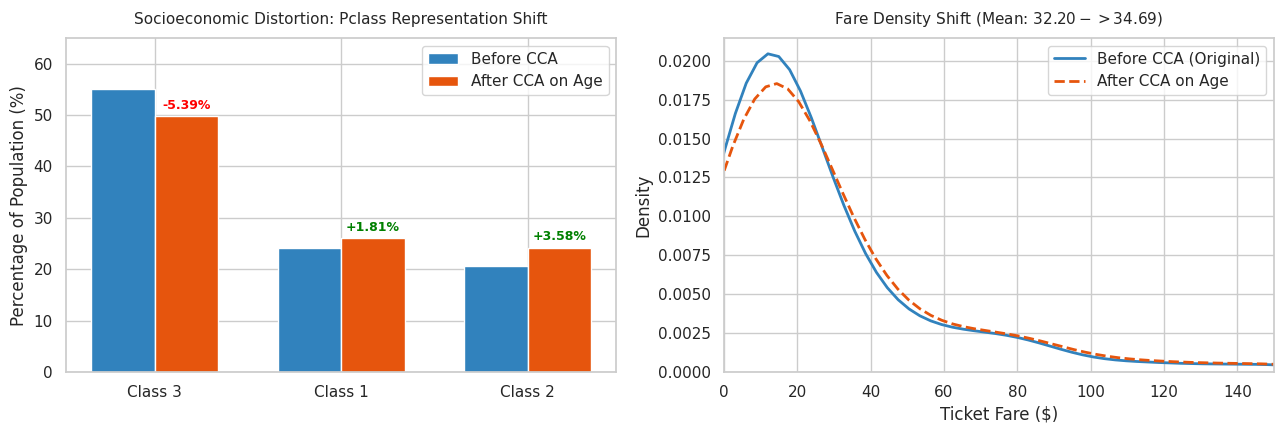

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Pclass representation shift
x_p = np.arange(len(pclass_shift))
axes[0].bar(x_p - 0.17, pclass_shift['Before (%)'], 0.34, label='Before CCA', color='#3182bd')
axes[0].bar(x_p + 0.17, pclass_shift['After (%)'], 0.34, label='After CCA on Age', color='#e6550d')
axes[0].set_title('Socioeconomic Distortion: Pclass Representation Shift', fontsize=11, pad=10)
axes[0].set_ylabel('Percentage of Population (%)')
axes[0].set_xticks(x_p)
axes[0].set_xticklabels([f"Class {c}" for c in pclass_shift.index])
axes[0].legend()
axes[0].set_ylim(0, 65)

for i in range(len(pclass_shift)):
    diff = pclass_shift['Difference (%)'].iloc[i]
    color = 'red' if diff < 0 else 'green'
    axes[0].text(x_p[i] + 0.17, pclass_shift['After (%)'].iloc[i] + 1.5, f"{diff:+.2f}%", ha='center', color=color, fontweight='bold', fontsize=9)

# Plot 2: Fare KDE density shift
sns.kdeplot(df['Fare'], ax=axes[1], label='Before CCA (Original)', color='#3182bd', linewidth=2)
sns.kdeplot(df_age_cca['Fare'], ax=axes[1], label='After CCA on Age', color='#e6550d', linewidth=2, linestyle='--')
axes[1].set_title('Fare Density Shift (Mean: $32.20 -> $34.69)', fontsize=11, pad=10)
axes[1].set_xlabel('Ticket Fare ($)')
axes[1].set_xlim(0, 150)
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Case Study 3: Catastrophic CCA on Extreme Missingness (`Cabin`)

### What are we doing?
`Cabin` is missing in **687 out of 891 rows (77.10%)**.
What happens if a beginner naively runs `df.dropna(subset=['Cabin'])`?


In [13]:
df_cabin_cca = df.dropna(subset=['Cabin'])

print(f"Original Dataset Size:          {len(df)} rows")
print(f"Dataset Size After Cabin CCA:   {len(df_cabin_cca)} rows")
print(f"Total Rows Destroyed:           {len(df) - len(df_cabin_cca)} rows ({((len(df) - len(df_cabin_cca))/len(df)*100):.1f}%)")

print("\nSurvival Rate Comparison:")
print(f"  True Population Survival Rate:      {df['Survived'].mean() * 100:.2f}%")
print(f"  Surviving Subset Survival Rate:     {df_cabin_cca['Survived'].mean() * 100:.2f}%")


Original Dataset Size:          891 rows
Dataset Size After Cabin CCA:   204 rows
Total Rows Destroyed:           687 rows (77.1%)

Survival Rate Comparison:
  True Population Survival Rate:      38.38%
  Surviving Subset Survival Rate:     66.67%


### Analysis of Catastrophic CCA

#### The Catastrophe:
1. **77.1% of all observations were destroyed**: You reduced a healthy dataset of 891 passengers down to a tiny fragment of 204 passengers.
2. **Survival rate jumped from 38.38% to 66.67%**: Because only wealthy 1st class passengers had recorded cabins, discarding missing rows created a luxury survivor sample that bears zero resemblance to reality!

#### The Proper Strategy:
When missingness is extreme ($> 70\%$):
- **Never drop rows via CCA.**
- **Drop the column entirely** (`df.drop(columns=['Cabin'])`), OR
- **Engineer a missingness indicator / deck feature** (as we implemented in [Module 03 Topic 09: Handling Mixed Variables](file:///Users/shamvi/stuff/ML/03_Feature_Engineering/09_Handling_Mixed_Variables/)).


## 9. Machine Learning Experiment: The Critical Production Dilemma

### What are we doing?
We build a K-Nearest Neighbors (KNN) classification pipeline on the complete cases of our training set to observe how CCA behaves in a machine learning workflow.

#### Why K-Nearest Neighbors (KNN)?
KNN relies on Euclidean distance calculations:
$$d(x, y) = \sqrt{\sum (x_i - y_i)^2}$$
If even one feature value is `NaN`, the distance calculation $(x_i - 	ext{NaN})^2 = 	ext{NaN}$, rendering nearest-neighbor ranking mathematically undefined. Distance-based models, linear models, and neural networks cannot natively handle missing data!

#### The Crucial Production Question:
What happens when your model is deployed into live production and a new customer submits an application with an unrecorded optional field?


In [14]:
# 1. Split raw data FIRST to prevent data leakage
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Raw Training Rows: {len(X_train)}, Raw Testing Rows: {len(X_test)}")

# 2. Apply Complete Case Analysis STRICTLY on the training set
train_complete_idx = X_train.dropna().index
X_train_cca = X_train.loc[train_complete_idx]
y_train_cca = y_train.loc[train_complete_idx]

print(f"Training Rows After CCA: {len(X_train_cca)} (Lost {len(X_train) - len(X_train_cca)} rows)")

# 3. Build preprocessing pipeline for complete cases
prep = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Fare']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['Pclass', 'Sex', 'Embarked'])
    ]
)

knn_cca_model = Pipeline([
    ('preprocessor', prep),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Fit model on complete training cases
knn_cca_model.fit(X_train_cca, y_train_cca)
print("Model trained successfully on complete cases!")


Raw Training Rows: 712, Raw Testing Rows: 179
Training Rows After CCA: 573 (Lost 139 rows)
Model trained successfully on complete cases!


### The Production Failure Test: Predicting on Raw Unseen Data

### What are we doing?
In a real-world web application, live incoming queries (`X_test`) will contain missing values (e.g. 36 passengers in `X_test` have missing `Age`).
Let's see what happens when we attempt to predict on `X_test` with our CCA-trained model.


In [15]:
# Attempting prediction on incoming test data containing nulls
try:
    preds = knn_cca_model.predict(X_test)
    print("Prediction succeeded!")
except ValueError as e:
    print("=" * 70)
    print("PRODUCTION EXCEPTION CAUGHT SUCCESSFULLY:")
    print(f"Exception Type: {type(e).__name__}")
    print(f"Error Message:  {str(e)[:80]}...")
    print("=" * 70)


PRODUCTION EXCEPTION CAUGHT SUCCESSFULLY:
Exception Type: ValueError
Error Message:  Input X contains NaN.
KNeighborsClassifier does not accept missing values encode...


### Evaluating on Complete Test Cases

### What does this prove?
`ValueError: Input X contains NaN`!
The algorithm crashes immediately because Euclidean distance cannot be calculated with `NaN`. In production, **you cannot simply delete the incoming customer**; you must return a prediction!

If the business policy explicitly allows rejecting incomplete requests, we evaluate strictly on complete test cases:


In [16]:
# Evaluate strictly on complete test cases
test_complete_idx = X_test.dropna().index
X_test_cca = X_test.loc[test_complete_idx]
y_test_cca = y_test.loc[test_complete_idx]

test_preds = knn_cca_model.predict(X_test_cca)
acc_complete = accuracy_score(y_test_cca, test_preds)

print(f"Evaluated on {len(X_test_cca)} Complete Test Samples (Discarded {len(X_test) - len(X_test_cca)} incomplete test samples)")
print(f"Model Accuracy on Complete Cases: {acc_complete * 100:.2f}%")


Evaluated on 139 Complete Test Samples (Discarded 40 incomplete test samples)
Model Accuracy on Complete Cases: 82.01%


---

## What We Learned
- **Mechanics of CCA (Listwise Deletion)**: Discards any observation that contains at least one missing value across the analyzed features.
- **The MCAR Assumption**: Complete Case Analysis is statistically unbiased **only** when missingness is Missing Completely At Random (pure chance).
- **The 5% Rule of Thumb**: CCA is easiest to justify when total row loss is $< 5\%$, but this is an empirical guide that must balance sample size and statistical power.
- **The Hazard of MAR/MNAR Missingness**: When missingness correlates with other variables (like `Age` missingness correlating with `Pclass`), CCA introduces severe selection bias (-5.39% loss of 3rd class passengers, +13.4% fare variance inflation).
- **Extreme Missingness ($> 70\%$)**: Applying CCA to features like `Cabin` destroys the dataset (77% row loss); such features should be dropped as columns or transformed into indicator flags.
- **Distribution Diagnostics**: Always verify that means, variances, and category proportions remain preserved before and after dropping rows.
- **The Production Bottleneck**: Standard models trained on CCA datasets will crash on live inference data containing nulls; production systems require explicit upstream validation or an imputation fallback.

---

## Important Takeaways
1. **Never apply `dropna()` blindly across an entire DataFrame**: Use `subset=['col']` to isolate specific low-missingness features.
2. **Diagnose missingness mechanisms first**: Check if null rates vary significantly across target classes or categorical features.
3. **Always compare before vs. after distributions**: If variance shifts by $>10\%$ or category proportions alter noticeably, reject CCA in favor of imputation.
4. **Prepare for production inference**: If incoming production queries can contain nulls, pair your model with an explicit imputer (like `SimpleImputer`).

---

## Common Mistakes
1. **Confusing dropping rows with dropping columns**: Running `df.dropna(subset=['Cabin'])` deletes 77% of rows, whereas `df.drop(columns=['Cabin'])` deletes 1 column while keeping 100% of rows!
2. **Assuming all missingness is random**: Overlooking that certain cohorts (e.g. lower socioeconomic classes) systematically fail to report data.
3. **Ignoring sample size in small datasets**: In a dataset of 100 rows, losing 5 rows (5%) can severely degrade model training stability.
4. **Deploying CCA models without a null-handling policy**: Allowing live production pipelines to crash when users submit optional blank fields.

---

## Final Mental Model

```text
                      Dataset With Missing Values
                                  │
                                  ▼
                    Evaluate Missing Percentage
                                  │
         ┌────────────────────────┴────────────────────────┐
         ▼                                                 ▼
      > 50–70%                                          < 5–10%
 (Feature is mostly empty)                         (Small missingness)
         │                                                 │
         ▼                                                 ▼
Drop Column / Create Missing Flag               Is Missingness MCAR?
                                                           │
                                        ┌──────────────────┴──────────────────┐
                                        ▼                                     ▼
                                    Yes (MCAR)                         No (MAR / MNAR)
                                        │                                     │
                                        ▼                                     ▼
                               Check Distributions                    Use Imputation
                                  Before vs After                     (Median, KNN)
                                        │
                         ┌──────────────┴──────────────┐
                         ▼                             ▼
                    Preserved?                      Altered?
                         │                             │
                         ▼                             ▼
                   Safe for CCA!                Use Imputation!
```
